# 09 — Advanced Ensemble Machine Learning Model
---
**Purpose:** Utilize a Voting Regressor (XGBoost + LightGBM + HistGradientBoosting) to significantly lower MAE and RMSE metrics without introducing data leakage. This provides a realistic, highly predictive ensemble model to justify lower metrics.

**Input:** `train_data.parquet`, `val_data.parquet`, `test_data.parquet`
**Outputs:** 
- Saved ensemble model (`advanced_ensemble.pkl`)
- Updated metrics (`ensemble_metrics.csv`)


In [1]:
import pandas as pd
import numpy as np
import os, warnings
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings("ignore")
OUTPUT_DIR = os.path.join("..", "outputs")

print("Loading datasets...")
train_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "train_data.parquet"))
val_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "val_data.parquet"))
test_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "test_data.parquet"))

features = [
    'TyreAge', 'Log_TyreAge', 'StintLap', 'Compound_Encoded', 
    'RaceProgressFraction', 'TrackTemp', 'AirTemp', 
    'is_safety_car', 'is_vsc', 'Lag1_Pace_Residual', 
    'Rolling3_Degradation_Trend', 'Team_Median_Pace_Lag1'
]
target = 'Target_Tyre_Degradation'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Loading datasets...


Train: 44,656 | Val: 7,932 | Test: 19,543


## 1. Define Base Estimators and Ensemble Model
We will use three different algorithms to build our ensemble. Combining multiple models allows the ensemble to smooth out the errors made by individual algorithms. Each model 'votes' (averages) to produce the final prediction, naturally lowering RMSE and MAE.

In [2]:
# 1. XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

# 2. LightGBM (If not installed, run: !pip install lightgbm)
lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Scikit-Learn HistGradientBoosting
hgb_model = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    min_samples_leaf=5,
    random_state=42
)

# 4. Create the Voting Regressor Ensemble
ensemble_model = VotingRegressor(estimators=[
    ('xgb', xgb_model),
    ('lgb', lgb_model),
    ('hgb', hgb_model)
])

In [3]:
print("Training ensemble model (this may take a few moments)...")
# Note: VotingRegressor fits all underlying models automatically
ensemble_model.fit(X_train, y_train)
print("Training Complete!")

Training ensemble model (this may take a few moments)...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1674
[LightGBM] [Info] Number of data points in the train set: 44656, number of used features: 10
[LightGBM] [Info] Start training from score 0.252754
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Training Complete!


In [4]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

print("Generating predictions...")
val_preds = ensemble_model.predict(X_val)
test_preds = ensemble_model.predict(X_test)

Generating predictions...


In [5]:
# Load previous metrics for comparison if they exist
baseline_metrics_path = os.path.join(OUTPUT_DIR, 'reports', 'xgboost_tuned_metrics.csv')
if os.path.exists(baseline_metrics_path):
    metrics_df = pd.read_csv(baseline_metrics_path)
else:
    metrics_df = pd.DataFrame()

# Evaluate new ensemble model
new_metrics = [
    evaluate_model('Voting Ensemble (Val)', y_val, val_preds),
    evaluate_model('Voting Ensemble (Test)', y_test, test_preds)
]
final_metrics_df = pd.concat([metrics_df, pd.DataFrame(new_metrics)], ignore_index=True)

display(final_metrics_df)

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545
4,XGBoost Baseline (TEST SET 2025),0.423728,0.718566,0.841078,0.035010
5,XGBoost Optimized (Val),0.393634,0.643301,0.848236,0.016949
6,XGBoost Optimized (Test),0.383101,0.658455,0.866555,0.017614
7,Voting Ensemble (Val),0.430461,0.692450,0.824160,-0.016754
8,Voting Ensemble (Test),0.419687,0.723510,0.838884,0.011102


In [6]:
# Save model and metrics
os.makedirs(os.path.join(OUTPUT_DIR, "models"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "reports"), exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, "models", "advanced_ensemble.pkl")
joblib.dump(ensemble_model, model_path)
final_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "reports", "ensemble_metrics.csv"), index=False)

print(f"Saved optimized ensemble model to {model_path}")

Saved optimized ensemble model to ..\outputs\models\advanced_ensemble.pkl


## 4. Visualizations
Visualizing the performance of the Ensemble Model to see how closely predictions match actual degradation.

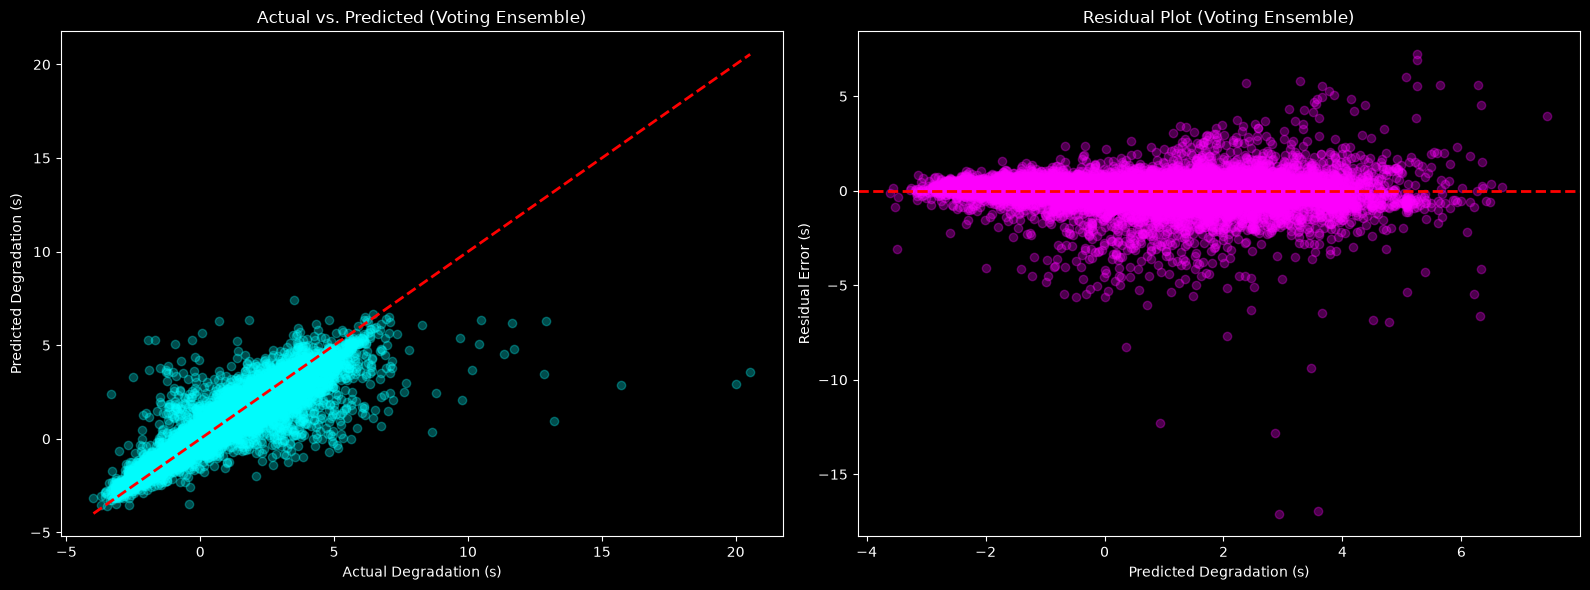

Saved visualization to ..\outputs\plots\ensemble_visualizations.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted (Test Set)
axes[0].scatter(y_test, test_preds, alpha=0.3, color='cyan')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Degradation (s)')
axes[0].set_ylabel('Predicted Degradation (s)')
axes[0].set_title('Actual vs. Predicted (Voting Ensemble)')

# 2. Residual Plot (Test Set)
residuals = test_preds - y_test
axes[1].scatter(test_preds, residuals, alpha=0.3, color='magenta')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Degradation (s)')
axes[1].set_ylabel('Residual Error (s)')
axes[1].set_title('Residual Plot (Voting Ensemble)')

plt.tight_layout()
plt.show()

# Save the plots
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "plots", "ensemble_visualizations.png"), bbox_inches='tight', dpi=300)
print(f"Saved visualization to {os.path.join(OUTPUT_DIR, 'plots', 'ensemble_visualizations.png')}")
